<a href="https://colab.research.google.com/github/AbenezerYBekele/Data-Analyst/blob/main/Customer_Shopping_Trends_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:

!pip install -q pandas sqlalchemy matplotlib

import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import os, warnings
warnings.filterwarnings("ignore")

os.makedirs("outputs", exist_ok=True)
print("Environment ready")

Environment ready


In [14]:

UPDATED_ID  = "1EAxL0ycEg2tTzLqrj27_4gTNEqoxJtVSpNWxHaNYkfk"
UPDATED_GID = "1889325951"
RAW_ID      = "1emkc25wVC3paIJRGTBpft7t6CDH6v4D4nBGeZghOTcc"
RAW_GID     = "920688681"

updated_url = f"https://docs.google.com/spreadsheets/d/{UPDATED_ID}/export?format=csv&gid={UPDATED_GID}"
raw_url     = f"https://docs.google.com/spreadsheets/d/{RAW_ID}/export?format=csv&gid={RAW_GID}"

df_updated = pd.read_csv(updated_url)
df_raw     = pd.read_csv(raw_url)

print(f"shopping_trends_updated : {df_updated.shape}")
print(f"shopping_trends         : {df_raw.shape}")
df_updated.head()

shopping_trends_updated : (3900, 18)
shopping_trends         : (3900, 19)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
def profile(df, name):
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(f"Shape          : {df.shape}")
    print(f"Duplicates     : {df.duplicated().sum()}")
    print(f"Null counts    :\n{df.isnull().sum()[df.isnull().sum() > 0]}")
    print(f"Data types     :\n{df.dtypes}")

profile(df_raw,     "RAW DATASET")
profile(df_updated, "UPDATED DATASET")


RAW DATASET
Shape          : (3900, 19)
Duplicates     : 0
Null counts    :
Series([], dtype: int64)
Data types     :
Customer ID                   int64
Age                           int64
Gender                       object
Item Purchased               object
Category                     object
Purchase Amount (USD)         int64
Location                     object
Size                         object
Color                        object
Season                       object
Review Rating               float64
Subscription Status          object
Payment Method               object
Shipping Type                object
Discount Applied             object
Promo Code Used              object
Previous Purchases            int64
Preferred Payment Method     object
Frequency of Purchases       object
dtype: object

UPDATED DATASET
Shape          : (3900, 18)
Duplicates     : 0
Null counts    :
Series([], dtype: int64)
Data types     :
Customer ID                 int64
Age                       

In [15]:
def clean(df):
    df = df.copy()

    df.columns = (
        df.columns.str.strip()
                  .str.replace(" (USD)", "", regex=False)
                  .str.replace(" ", "_")
                  .str.lower()
    )
    df.rename(columns={"customer_id": "customer_id"}, inplace=True)

    before = len(df)
    df = df.drop_duplicates(subset=["customer_id"], keep="first")
    print(f"Dropped {before - len(df)} duplicate customer rows")

    df["purchase_amount"] = pd.to_numeric(df["purchase_amount"], errors="coerce")
    df["review_rating"]   = pd.to_numeric(df["review_rating"],   errors="coerce")
    df["age"]             = pd.to_numeric(df["age"],             errors="coerce")

    for c in df.select_dtypes(include="object").columns:
        df[c] = df[c].astype(str).str.strip()

    df = df[
        (df["purchase_amount"].between(1, 500)) &
        (df["review_rating"].between(1, 5)) &
        (df["age"].between(18, 100))
    ]

    return df

df_clean = clean(df_raw)
print(f"\nCleaned: {df_clean.shape}")
df_clean.head()

Dropped 0 duplicate customer rows

Cleaned: (3900, 19)


,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,payment_method,shipping_type,discount_applied,promo_code_used,previous_purchases,preferred_payment_method,frequency_of_purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [16]:
def add_features(df):
    df = df.copy()

    df["age_group"] = pd.cut(
        df["age"],
        bins=[17, 24, 34, 49, 64, 100],
        labels=["18-24", "25-34", "35-49", "50-64", "65+"]
    ).astype(str)

    df["revenue_band"] = pd.cut(
        df["purchase_amount"],
        bins=[0, 30, 60, 100],
        labels=["Low", "Medium", "High"]
    ).astype(str)

    df["rating_sentiment"] = pd.cut(
        df["review_rating"],
        bins=[0, 2.5, 4.0, 5.0],
        labels=["Negative", "Neutral", "Positive"]
    ).astype(str)

    return df

df_clean = add_features(df_clean)
print("Features added:", df_clean.shape)
df_clean[["customer_id", "age_group", "revenue_band", "rating_sentiment"]].head()

Features added: (3900, 22)


,customer_id,age_group,revenue_band,rating_sentiment
0,1,50-64,Medium,Neutral
1,2,18-24,High,Neutral
2,3,50-64,High,Neutral
3,4,18-24,High,Neutral
4,5,35-49,Medium,Neutral


In [18]:

DB_PATH = "outputs/shopping_trends.db"
conn = sqlite3.connect(DB_PATH)
cur  = conn.cursor()

cur.executescript("""
DROP TABLE IF EXISTS fact_purchase;
DROP TABLE IF EXISTS dim_customer;
DROP TABLE IF EXISTS dim_item;
DROP TABLE IF EXISTS dim_location;
DROP TABLE IF EXISTS dim_payment;
DROP TABLE IF EXISTS stg_shopping;

-- Staging
CREATE TABLE stg_shopping AS SELECT 1 WHERE 0;

-- Dimensions
CREATE TABLE dim_customer (
    customer_key INTEGER PRIMARY KEY AUTOINCREMENT,
    customer_id INTEGER UNIQUE,
    age INTEGER,
    age_group TEXT,
    gender TEXT,
    subscription_status TEXT,
    previous_purchases INTEGER,
    frequency_of_purchases TEXT
);

CREATE TABLE dim_item (
    item_key INTEGER PRIMARY KEY AUTOINCREMENT,
    item_purchased TEXT,
    category TEXT,
    size TEXT,
    color TEXT,
    UNIQUE(item_purchased, size, color)
);

CREATE TABLE dim_location (
    location_key INTEGER PRIMARY KEY AUTOINCREMENT,
    location TEXT UNIQUE
);

CREATE TABLE dim_payment (
    payment_key INTEGER PRIMARY KEY AUTOINCREMENT,
    payment_method TEXT,
    shipping_type TEXT,
    UNIQUE(payment_method, shipping_type)
);

-- Fact
CREATE TABLE fact_purchase (
    purchase_key INTEGER PRIMARY KEY AUTOINCREMENT,
    customer_key INTEGER,
    item_key INTEGER,
    location_key INTEGER,
    payment_key INTEGER,
    purchase_amount REAL,
    review_rating REAL,
    season TEXT,
    discount_applied TEXT,
    promo_code_used TEXT,
    revenue_band TEXT,
    rating_sentiment TEXT,
    FOREIGN KEY(customer_key) REFERENCES dim_customer(customer_key),
    FOREIGN KEY(item_key)     REFERENCES dim_item(item_key),
    FOREIGN KEY(location_key) REFERENCES dim_location(location_key),
    FOREIGN KEY(payment_key)  REFERENCES dim_payment(payment_key)
);
""")
conn.commit()
print("Star schema created")

Star schema created


In [21]:

import sqlite3

cur.executescript("""
DELETE FROM fact_purchase;
DELETE FROM dim_customer;
DELETE FROM dim_item;
DELETE FROM dim_location;
DELETE FROM dim_payment;

-- Reset AUTOINCREMENT counters so keys start at 1 again
DELETE FROM sqlite_sequence
 WHERE name IN ('fact_purchase','dim_customer','dim_item','dim_location','dim_payment');
""")
conn.commit()
print("Warehouse tables truncated")

dim_customer = df_clean[[
    "customer_id", "age", "age_group", "gender",
    "subscription_status", "previous_purchases", "frequency_of_purchases"
]].drop_duplicates(subset=["customer_id"])
dim_customer.to_sql("dim_customer", conn, if_exists="append", index=False)
print(f" dim_customer : {len(dim_customer)} rows")

dim_item = df_clean[["item_purchased", "category", "size", "color"]].drop_duplicates()
dim_item.to_sql("dim_item", conn, if_exists="append", index=False)
print(f"dim_item     : {len(dim_item)} rows")

dim_location = df_clean[["location"]].drop_duplicates()
dim_location.to_sql("dim_location", conn, if_exists="append", index=False)
print(f"dim_location : {len(dim_location)} rows")

dim_payment = df_clean[["payment_method", "shipping_type"]].drop_duplicates()
dim_payment.to_sql("dim_payment", conn, if_exists="append", index=False)
print(f"dim_payment  : {len(dim_payment)} rows")

fact = (
    df_clean.merge(
        pd.read_sql("SELECT customer_key, customer_id FROM dim_customer", conn),
        on="customer_id"
    ).merge(
        pd.read_sql("SELECT item_key, item_purchased, size, color FROM dim_item", conn),
        on=["item_purchased", "size", "color"]
    ).merge(
        pd.read_sql("SELECT location_key, location FROM dim_location", conn),
        on="location"
    ).merge(
        pd.read_sql("SELECT payment_key, payment_method, shipping_type FROM dim_payment", conn),
        on=["payment_method", "shipping_type"]
    )
)

fact_final = fact[[
    "customer_key", "item_key", "location_key", "payment_key",
    "purchase_amount", "review_rating", "season",
    "discount_applied", "promo_code_used", "revenue_band", "rating_sentiment"
]]
fact_final.to_sql("fact_purchase", conn, if_exists="append", index=False)
print(f"fact_purchase: {len(fact_final)} rows")

df_clean.to_sql("stg_shopping", conn, if_exists="replace", index=False)

print("\n Warehouse populated successfully")
print(pd.read_sql("SELECT COUNT(*) AS rows FROM fact_purchase", conn))

Warehouse tables truncated
 dim_customer : 3900 rows
dim_item     : 1823 rows
dim_location : 50 rows
dim_payment  : 36 rows
fact_purchase: 3900 rows

 Warehouse populated successfully
   rows
0  3900


In [22]:

dq = pd.read_sql("""
SELECT
    (SELECT COUNT(*) FROM stg_shopping)                AS staging_rows,
    (SELECT COUNT(*) FROM fact_purchase)               AS fact_rows,
    (SELECT COUNT(*) FROM dim_customer)                AS customers,
    (SELECT COUNT(*) FROM dim_item)                    AS items,
    (SELECT COUNT(*) FROM dim_location)                AS locations,
    (SELECT COUNT(DISTINCT payment_key) FROM fact_purchase) AS payment_methods,
    (SELECT COUNT(*) FROM fact_purchase WHERE purchase_amount <= 0) AS invalid_amounts,
    (SELECT COUNT(*) FROM fact_purchase WHERE review_rating NOT BETWEEN 1 AND 5) AS invalid_ratings
""", conn)
print(dq.T)

ri = pd.read_sql("""
SELECT COUNT(*) AS orphan_facts
FROM fact_purchase f
LEFT JOIN dim_customer c ON f.customer_key = c.customer_key
LEFT JOIN dim_item     i ON f.item_key     = i.item_key
WHERE c.customer_key IS NULL OR i.item_key IS NULL
""", conn)
print("\nReferential integrity:\n", ri)

dq.to_csv("outputs/data_quality_report.csv", index=False)
print("Saved outputs/data_quality_report.csv")

                    0
staging_rows     3900
fact_rows        3900
customers        3900
items            1823
locations          50
payment_methods    36
invalid_amounts     0
invalid_ratings     0

Referential integrity:
    orphan_facts
0             0
Saved outputs/data_quality_report.csv


In [23]:

cur.executescript("""
DROP VIEW IF EXISTS vw_revenue_by_category;
CREATE VIEW vw_revenue_by_category AS
SELECT i.category,
       COUNT(*) AS transactions,
       ROUND(SUM(f.purchase_amount), 2) AS revenue,
       ROUND(AVG(f.purchase_amount), 2) AS avg_order_value
FROM fact_purchase f
JOIN dim_item i ON f.item_key = i.item_key
GROUP BY i.category;

DROP VIEW IF EXISTS vw_customer_segments;
CREATE VIEW vw_customer_segments AS
SELECT c.age_group, c.gender,
       COUNT(DISTINCT c.customer_key) AS num_customers,
       ROUND(SUM(f.purchase_amount), 2) AS total_spend,
       ROUND(AVG(f.purchase_amount), 2) AS avg_spend
FROM fact_purchase f
JOIN dim_customer c ON f.customer_key = c.customer_key
GROUP BY c.age_group, c.gender;

DROP VIEW IF EXISTS vw_seasonal_trends;
CREATE VIEW vw_seasonal_trends AS
SELECT f.season, i.category,
       COUNT(*) AS orders,
       ROUND(SUM(f.purchase_amount), 2) AS revenue
FROM fact_purchase f
JOIN dim_item i ON f.item_key = i.item_key
GROUP BY f.season, i.category;

DROP VIEW IF EXISTS vw_subscription_impact;
CREATE VIEW vw_subscription_impact AS
SELECT c.subscription_status,
       COUNT(*) AS transactions,
       ROUND(SUM(f.purchase_amount), 2) AS revenue,
       ROUND(AVG(f.purchase_amount), 2) AS avg_order_value
FROM fact_purchase f
JOIN dim_customer c ON f.customer_key = c.customer_key
GROUP BY c.subscription_status;
""")
conn.commit()
print(" Views created")

 Views created


In [24]:

queries = {
    "revenue_by_category": "SELECT * FROM vw_revenue_by_category ORDER BY revenue DESC",
    "top_10_items": """
        SELECT i.item_purchased, ROUND(SUM(f.purchase_amount),2) AS revenue
        FROM fact_purchase f JOIN dim_item i ON f.item_key = i.item_key
        GROUP BY i.item_purchased ORDER BY revenue DESC LIMIT 10
    """,
    "customer_segments": "SELECT * FROM vw_customer_segments ORDER BY total_spend DESC LIMIT 10",
    "seasonal_trends": "SELECT * FROM vw_seasonal_trends ORDER BY revenue DESC LIMIT 10",
    "subscription_impact": "SELECT * FROM vw_subscription_impact",
    "shipping_pref": """
        SELECT p.shipping_type,
               COUNT(*) AS orders,
               ROUND(AVG(f.review_rating),2) AS avg_rating,
               ROUND(SUM(f.purchase_amount),2) AS revenue
        FROM fact_purchase f JOIN dim_payment p ON f.payment_key = p.payment_key
        GROUP BY p.shipping_type ORDER BY revenue DESC
    """,
    "promo_effectiveness": """
        SELECT promo_code_used, discount_applied,
               COUNT(*) AS orders,
               ROUND(AVG(purchase_amount),2) AS aov,
               ROUND(SUM(purchase_amount),2) AS revenue
        FROM fact_purchase GROUP BY promo_code_used, discount_applied
    """
}

results = {}
for name, q in queries.items():
    df_q = pd.read_sql(q, conn)
    results[name] = df_q
    df_q.to_csv(f"outputs/{name}.csv", index=False)
    print(f"\n{'='*60}\n{name.upper()}\n{'='*60}")
    print(df_q.to_string(index=False))


REVENUE_BY_CATEGORY
   category  transactions  revenue  avg_order_value
   Clothing          1737 104264.0            60.03
Accessories          1240  74200.0            59.84
   Footwear           599  36093.0            60.26
  Outerwear           324  18524.0            57.17

TOP_10_ITEMS
item_purchased  revenue
        Blouse  10410.0
         Shirt  10332.0
         Dress  10320.0
         Pants  10090.0
       Jewelry  10010.0
    Sunglasses   9649.0
          Belt   9635.0
         Scarf   9561.0
       Sweater   9462.0
        Shorts   9433.0

CUSTOMER_SEGMENTS
age_group gender  num_customers  total_spend  avg_spend
    50-64   Male            770      45836.0      59.53
    35-49   Male            733      43642.0      59.54
    25-34   Male            514      30427.0      59.20
    50-64 Female            362      22080.0      60.99
    35-49 Female            367      21371.0      58.23
    18-24   Male            334      20078.0      60.11
      65+   Male            30

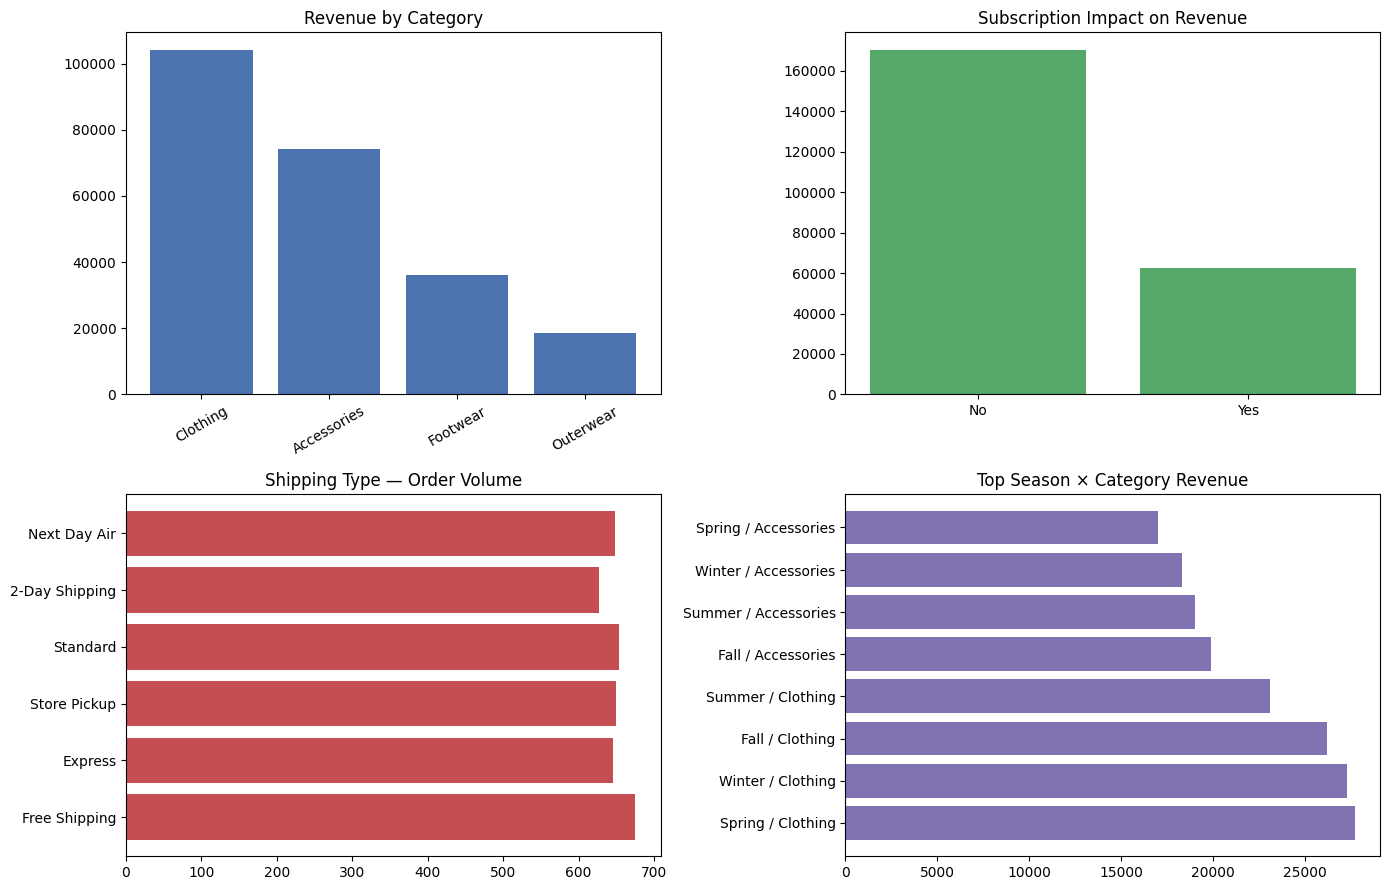

✅ Saved outputs/insights_dashboard.png


In [25]:

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

df = results["revenue_by_category"]
axes[0,0].bar(df["category"], df["revenue"], color="#4C72B0")
axes[0,0].set_title("Revenue by Category"); axes[0,0].tick_params(axis='x', rotation=30)

df = results["subscription_impact"]
axes[0,1].bar(df["subscription_status"], df["revenue"], color="#55A868")
axes[0,1].set_title("Subscription Impact on Revenue")

df = results["shipping_pref"]
axes[1,0].barh(df["shipping_type"], df["orders"], color="#C44E52")
axes[1,0].set_title("Shipping Type — Order Volume")

df = results["seasonal_trends"].head(8)
axes[1,1].barh(df["season"] + " / " + df["category"], df["revenue"], color="#8172B2")
axes[1,1].set_title("Top Season × Category Revenue")

plt.tight_layout()
plt.savefig("outputs/insights_dashboard.png", dpi=150)
plt.show()
print(" Saved outputs/insights_dashboard.png")

In [26]:

import shutil
shutil.make_archive("shopping_trends_portfolio", "zip", "outputs")
print("Created shopping_trends_portfolio.zip")

from google.colab import files
files.download("shopping_trends_portfolio.zip")

Created shopping_trends_portfolio.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>